In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/StudentPerformanceFactors.csv")

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [2]:
# Basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   str    
 3   Access_to_Resources         6605 non-null   str    
 4   Extracurricular_Activities  6605 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   str    
 8   Internet_Access             6606 non-null   str    
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   str    
 11  Teacher_Quality             6528 non-null   str    
 12  School_Type                 6605 non-null   str    
 13  Peer_Influence              6606 non-null   

In [3]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum().sort_values(ascending=False))

Missing Values:

Parental_Education_Level      90
Teacher_Quality               79
Distance_from_Home            68
Physical_Activity              3
School_Type                    2
Access_to_Resources            2
Attendance                     2
Hours_Studied                  2
Exam_Score                     2
Extracurricular_Activities     2
Parental_Involvement           1
Internet_Access                1
Motivation_Level               1
Peer_Influence                 1
Family_Income                  1
Tutoring_Sessions              1
Gender                         1
Previous_Scores                0
Sleep_Hours                    0
Learning_Disabilities          0
dtype: int64


In [4]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
# Analyze Exam Score

print("Exam Score Statistics:")
print(df["Exam_Score"].describe())

Exam Score Statistics:
count    6605.000000
mean       67.215291
std         4.217186
min       -65.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [6]:
# Check minimum and maximum exam scores

print("Minimum Score:", df["Exam_Score"].min())
print("Maximum Score:", df["Exam_Score"].max())
print("Average Score:", df["Exam_Score"].mean())

Minimum Score: -65.0
Maximum Score: 101.0
Average Score: 67.21529144587434


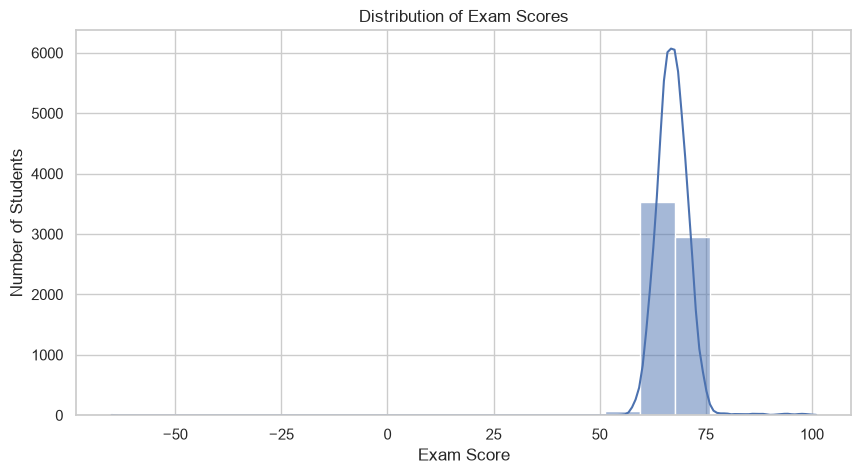

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set_theme(style="whitegrid")

# Exam Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Exam_Score"], bins=20, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

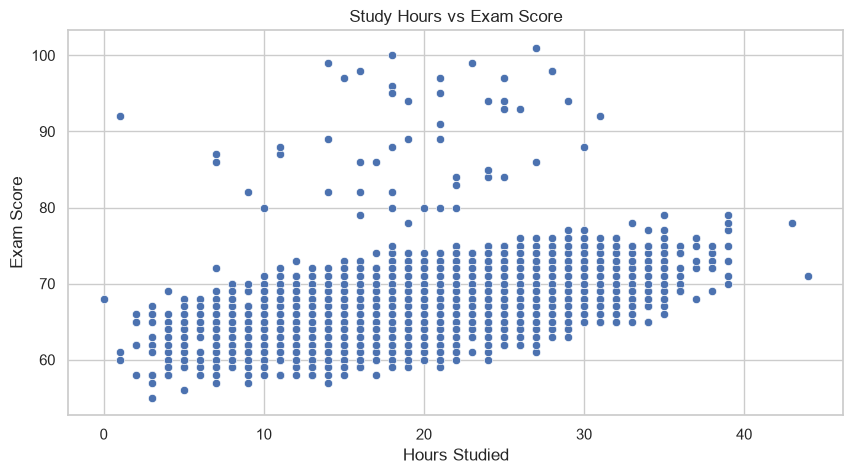

In [9]:
# Study Hours vs Exam Score

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

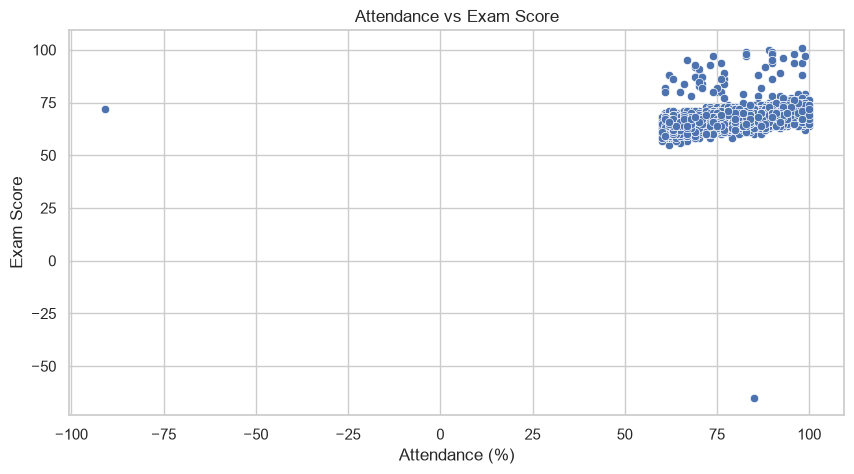

In [10]:
# Attendance vs Exam Score

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.show()

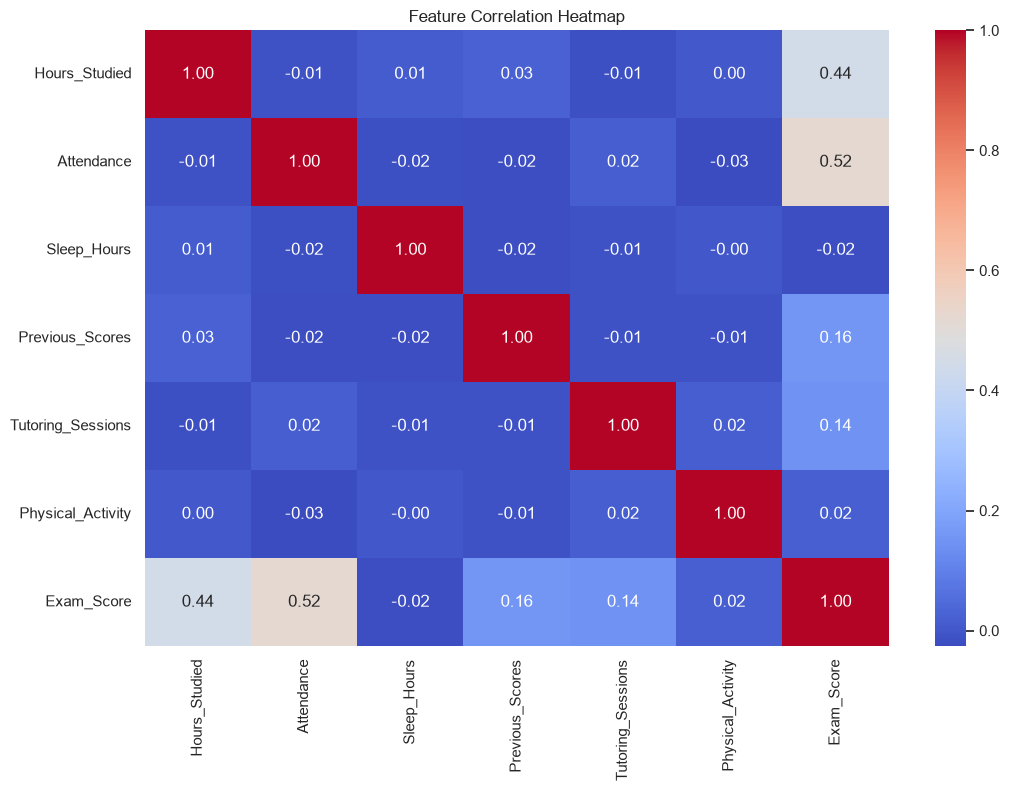

In [11]:
# Correlation Heatmap

numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
# Separate features and target

X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [13]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [16]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5285
Testing samples: 1322


In [18]:
# Remove rows where Exam_Score is missing

df_model = df.dropna(subset=["Exam_Score"]).copy()

print("Original rows:", len(df))
print("Rows after removing missing Exam_Score:", len(df_model))
print("Missing Exam_Score:", df_model["Exam_Score"].isnull().sum())

Original rows: 6607
Rows after removing missing Exam_Score: 6605
Missing Exam_Score: 0


In [19]:
# Re-create X and y after removing missing target values

X = df_model.drop("Exam_Score", axis=1)
y = df_model["Exam_Score"]

# Identify feature types again
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Features:", X.shape)
print("Target:", y.shape)
print("Missing target values:", y.isnull().sum())

Features: (6605, 19)
Target: (6605,)
Missing target values: 0


In [20]:
# Split the cleaned data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5284
Testing samples: 1321


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Create Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae_linear, 2))
print("MSE :", round(mse_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Performance
-----------------------------
MAE : 0.51
MSE : 4.22
RMSE: 2.05
R²  : 0.7083


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("MSE :", round(mse_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Performance
-------------------------
MAE : 1.13
MSE : 5.38
RMSE: 2.32
R²  : 0.6277


In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2 Score": [r2_linear, r2_rf]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("Model Comparison")
print("=================")
display(comparison)

Model Comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.512988,2.053894,0.70828
1,Random Forest,1.132328,2.320253,0.62771


In [27]:
if r2_rf > r2_linear:
    best_model = random_forest_model
    best_model_name = "Random Forest"
    best_r2 = r2_rf
else:
    best_model = linear_model
    best_model_name = "Linear Regression"
    best_r2 = r2_linear

print("Best Model:", best_model_name)
print("Best R² Score:", round(best_r2, 4))

Best Model: Linear Regression
Best R² Score: 0.7083


In [28]:
import joblib
import os

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

# Save the best model
joblib.dump(best_model, "../models/student_performance_model.pkl")

print("Best model saved successfully!")
print("Model:", best_model_name)
print("R² Score:", round(best_r2, 4))

Best model saved successfully!
Model: Linear Regression
R² Score: 0.7083
